In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Đã nạp xong các thư viện cần thiết.")

Đã nạp xong các thư viện cần thiết.


In [ ]:
def parse_log_file(filepath):
    """Đọc file log và chuyển thành cấu trúc DataFrame của Pandas."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    current_case = {}
    for line in lines:
        line = line.strip()
        if line.startswith("Query:"):
            if current_case:
                data.append(current_case)

            # Tách Query, Truth và Distance
            match = re.search(r'Query:\s*(.*),\s*Truth:\s*(.*?),\s*Distance:\s*(\d+)', line)
            if match:
                current_case = {
                    'query_zh': match.group(1),
                    'truth_zh': match.group(2).split(',')[0],
                    'distance': int(match.group(3))
                }
    if current_case:
        data.append(current_case)

    return pd.DataFrame(data)

# Đọc toàn bộ dữ liệu từ 2 file
df_fail = parse_log_file('fail.txt')
df_success = parse_log_file('success.txt')

print(f"Đã trích xuất: {len(df_fail)} ca thất bại, {len(df_success)} ca thành công.")

# print(df_fail.head(10))

# print(df_success.head(10))

Đã trích xuất: 5714 ca thất bại, 2879 ca thành công.
                query_zh              truth_zh  distance
0  4号大街与9号大街交叉口西侧盛泰北(2门)           盛泰·时代山(北2门)       664
1             紫丁香街向南物美超市            物美大卖场(丁桥店)       603
2    23号搭接和18号大街交叉口公司北大门  摩菲伊肯控制技术(杭州)有限公司(北门)       900
3      杭州市人民小学北面崇盛里小区7号楼                 崇盛里7幢       458
4             保利国际会所北停车场         国家电网杭州供电公司停车场     18316
5                星光荟对面美术    中国美术学院象山中心校区-美术教育系       524
6     桂花西路与新兴路交叉口西200米银行            华夏银行(富阳支行)     29378
7               紫金路东侧风尚4                 锋尚苑4幢     14470
8             爱国主题公园旁停车场            停车场(行知中学西)       719
9        联庄过渡房斜对面大厦停车场出入          彩宏大厦停车场(出入口)     18059
                                   query_zh                    truth_zh  \
0          浙江大学紫金港校区海洋大楼南侧浙江大学建筑工程学院A楼(南大门)            浙江大学建筑工程学院A楼(南门)   
1                           文三西路265号香港城2停车处                      香港城停车场   
2                             之江路西北面美正花苑32幢                    美政花苑32号楼   
3                跑马场

In [ ]:
def categorize_error_zh(row):
    """Phân loại lỗi dựa trên từ khóa Tiếng Trung và gán nhãn Tiếng Việt."""
    query_zh = str(row['query_zh'])
    distance = row['distance']

    # 1. LỖI KHÔNG GIAN (Mô hình dự đoán chệch quá 1000 đơn vị khoảng cách)
    if distance > 1000:
        return 'Lỗi Không gian\n(> 1000 đơn vị)'

    # 2. LỖI TỪ VỰNG - NHIỄU (Dự đoán gần đúng khu vực nhưng sai POI chi tiết)
    # Các từ khóa tiếng Trung thường gây nhiễu cho mô hình Unsupervised
    intersection_kws = ['交叉口', '路口', '大街', '路'] # Ngã tư, giao lộ, đường lớn
    directional_kws = ['侧', '方向', '南', '北', '东', '西', '附近'] # Phía, hướng, Đông/Tây/Nam/Bắc, gần đó

    has_intersection = any(kw in query_zh for kw in intersection_kws)
    has_direction = any(kw in query_zh for kw in directional_kws)

    if has_intersection and has_direction:
        return 'Nhiễu Phức hợp\n(Giao lộ + Phương hướng)'
    elif has_intersection:
        return 'Nhiễu Cấu trúc\n(Giao lộ / Đường)'
    elif has_direction:
        return 'Nhiễu Phương hướng\n(Đông, Tây, Nam, Bắc)'

    # 3. LỖI KHÁC (Truy vấn thiếu thông tin hoặc cấu trúc lạ)
    return 'Lỗi Mơ hồ / Khác'

# Áp dụng logic phân loại cho toàn bộ DataFrame thất bại
df_fail['error_type'] = df_fail.apply(categorize_error_zh, axis=1)

# Thống kê số lượng
error_counts = df_fail['error_type'].value_counts()
print("Phân phối nguyên nhân lỗi:")
print(error_counts)

Phân phối nguyên nhân lỗi:
error_type
Lỗi Không gian\n(> 1000 đơn vị)              2710
Nhiễu Phức hợp\n(Giao lộ + Phương hướng)     1376
Nhiễu Phương hướng\n(Đông, Tây, Nam, Bắc)    1075
Lỗi Mơ hồ / Khác                              347
Nhiễu Cấu trúc\n(Giao lộ / Đường)             206
Name: count, dtype: int64


In [ ]:
# Lấy dòng dữ liệu có khoảng cách lỗi lớn nhất
max_error_case = df_fail.loc[df_fail['distance'].idxmax()]

print("Khoảng cách lệch dài nhất:", max_error_case['distance'])
print("Câu truy vấn (Gốc):", max_error_case['query_zh'])
print("Đáp án đúng (Gốc):", max_error_case['truth_zh'])

Khoảng cách lệch dài nhất: 202742
Câu truy vấn (Gốc): 大创小镇文体中心(建设中)附近科技产业园2东门
Đáp án đúng (Gốc): 正泰中自科技园2(东门)


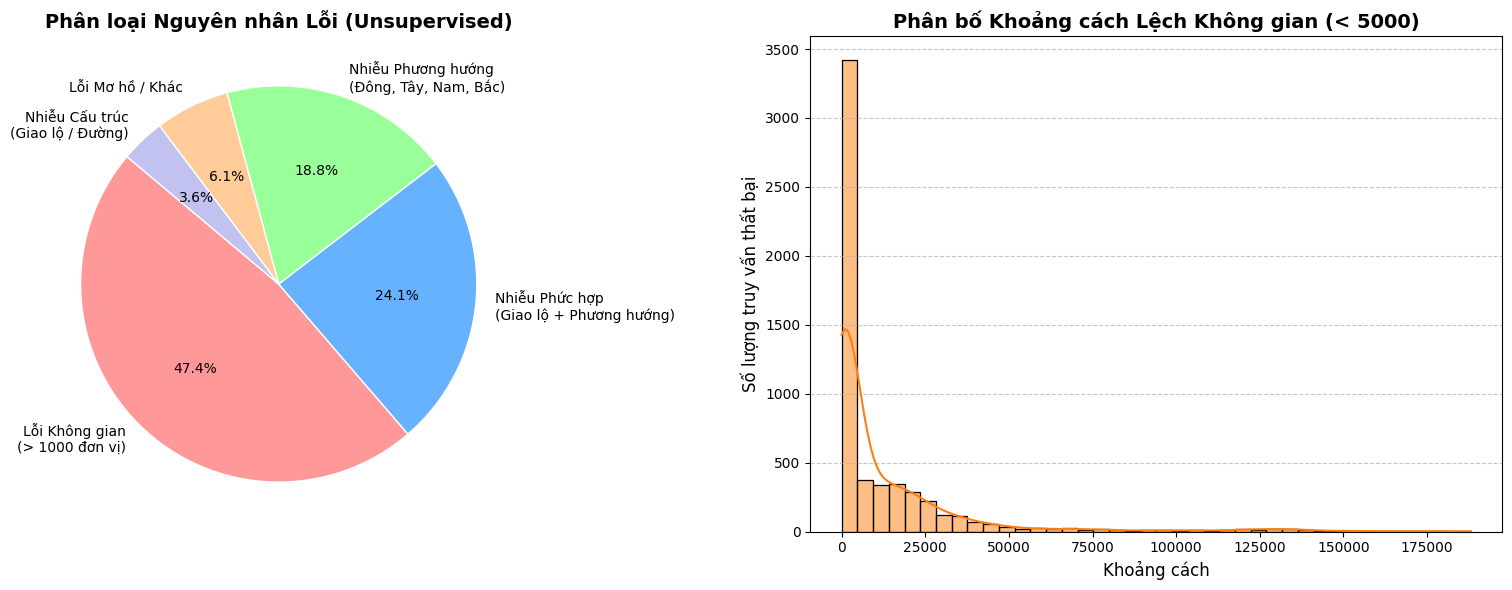

In [ ]:
def visualize_errors_overview(error_counts_series, df_full_fail):
    """Vẽ biểu đồ phân phối lỗi và khoảng cách lệch."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ 1: Pie Chart - Tỷ lệ nguyên nhân lỗi
    colors = ['#ff9999', '#66b2ff', '#99ff99', '#ffcc99', '#c2c2f0']
    axes[0].pie(
        error_counts_series.values,
        labels=error_counts_series.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'white'}
    )
    axes[0].set_title('Phân loại Nguyên nhân Lỗi (Unsupervised)', fontsize=14, fontweight='bold')

    # Biểu đồ 2: Histogram - Phân bố khoảng cách lệch
    filtered_distances = df_full_fail[df_full_fail['distance'] <= 200000]['distance']
    sns.histplot(
        filtered_distances,
        bins=40,
        ax=axes[1],
        color='#ff7f0e',
        kde=True
    )
    axes[1].set_title('Phân bố Khoảng cách Lệch Không gian (< 5000)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Khoảng cách', fontsize=12)
    axes[1].set_ylabel('Số lượng truy vấn thất bại', fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Gọi hàm thực thi trực quan hóa
visualize_errors_overview(error_counts, df_fail)